# Chapter 1.3. 실습 환경 세팅: Gymnasium — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter01_3_gymnasium_cartpole.ipynb)

책 본문: [1.3 실습 환경 세팅: Gymnasium](https://smhanlab.com/book-ml/kor/ml2/chapter01/3.html)

이 노트북은 1.3절의 내용을 코드로 직접 확인합니다:
(1) `gym.make`로 환경을 만들고 관찰/행동 **공간(space)**을 읽는 법,
(2) `reset`/`step` 계약과 무작위 정책 실행, (3) `reset`·`action_space.seed`
으로 재현성을 잡는 법, (4) `terminated`와 `truncated`를 구분하는 이유,
(5) 무작위 정책의 **베이스라인**(평균 버틴 스텝 수)을 수치로 잡는 법,
(6) 한 에피소드의 관측 궤적을 시각화, (7) 이산(CartPole)과 연속(Pendulum)
행동 공간의 비교.


## 1. 환경 만들기: `gym.make`와 관찰/행동 공간

`gym.make("CartPole-v1")`은 이름으로 환경을 만듭니다. `observation_space`와
`action_space`를 출력하면 "이 환경이 에이전트에게 무엇을 보여주고, 에이전트가
무엇을 선택할 수 있는가"가 한눈에 보입니다.


In [1]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")   # 막대를 쓰러뜨리지 않고 균형 잡기
obs, info = env.reset(seed=0)   # 에피소드 시작 -> 초기 관측

print("환경 타입 :", type(env).__name__)   # TimeLimit 래퍼가 감싸 있음
print("이름       :", env.spec.id)
print("관측 공간 :", env.observation_space)
print("행동 공간 :", env.action_space, "| 행동 개수 n =", env.action_space.n)
print("초기 관측 :", obs)   # [x, x_dot, theta, theta_dot]
print("초기 info :", info)
env.close()


환경 타입 : TimeLimit
이름       : CartPole-v1
관측 공간 : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
행동 공간 : Discrete(2) | 행동 개수 n = 2
초기 관측 : [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
초기 info : {}


**관측은 4차원 벡터** \([x, \dot{x}, \theta, \dot{\theta}]\) — 카트
위치·속도, 막대 각도·각속도 — 입니다. 위치만으로는 "아직 기울어지고 있는
중인가, 멈추고 있는가"를 알 수 없으므로 **속도까지** 주어야 상태가 완전히
기술됩니다(Chapter 4의 MDP 상태 \(s_t\)와 대응). 행동 공간은 `Discrete(2)`로
**이산** — 왼쪽(0)/오른쪽(1) 두 개뿐입니다.


## 2. `reset`/`step` 계약: 무작위 정책 3스텝 실행

본문의 "CartPole에서 무작위 정책 실행해보기" 코드를 그대로 실행합니다.
`step`은 다음 관측·보상·`terminated`·`truncated`·`info` **5개**를 돌려줍니다.


In [2]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)
print("초기 상태(카트 위치, 속도, 막대 각도, 각속도):", obs)

for _ in range(3):
    action = env.action_space.sample()  # 지금은 무작위 정책
    obs, reward, terminated, truncated, info = env.step(action)
    print("행동:", action,
          "-> 다음 상태:", np.round(obs, 4),
          "보상:", reward,
          "terminated:", terminated, "truncated:", truncated)
env.close()


초기 상태(카트 위치, 속도, 막대 각도, 각속도): [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
행동: 0 -> 다음 상태: [ 0.0132 -0.2175 -0.0469  0.2295] 보상: 1.0 terminated: False truncated: False
행동: 1 -> 다음 상태: [ 0.0089 -0.0217 -0.0423 -0.0776] 보상: 1.0 terminated: False truncated: False
행동: 1 -> 다음 상태: [ 0.0085  0.174  -0.0438 -0.3833] 보상: 1.0 terminated: False truncated: False


매 스텝 보상은 **+1**(아직 살아 있는가)입니다. `env.action_space.sample()`로
완전 무작위로 움직이지만, Chapter 2~11에서 이 한 줄이 "배운 알고리즘이 고른
행동"으로 바뀝니다.


## 3. 재현성: `reset`의 시드와 `action_space.seed`

강화학습은 확률적이므로 같은 코드를 돌려도 결과가 달라지는 것은 **정상**입니다.
재현성을 위해 초기 상태(`reset(seed=...)`)와 행동 무작위성
(`action_space.seed(...)`)을 **별도로** 고정합니다. 두 시드는 **독립**된
스트림입니다.


In [3]:
env = gym.make("CartPole-v1")

# 초기 상태: 같은 시드 -> 같은 관측
obs1, _ = env.reset(seed=42)
obs2, _ = env.reset(seed=42)
print("같은 시드 -> 같은 초기 관측:", np.allclose(obs1, obs2))

# 행동 무작위성: action_space.seed()을 별도로 줘야 고정됨
env.action_space.seed(7); a1 = env.action_space.sample()
env.action_space.seed(7); a2 = env.action_space.sample()
print("같은 시드 -> 같은 행동:", a1 == a2)

# 주의: reset(seed=...)은 행동 무작위성을 자동 고정하지 않는다
env.reset(seed=5); b1 = env.action_space.sample()
env.reset(seed=5); b2 = env.action_space.sample()
print("reset만 고정하면 첫 행동이 매번 다를 수 있다:", b1, b2)
env.close()


같은 시드 -> 같은 초기 관측: True
같은 시드 -> 같은 행동: True
reset만 고정하면 첫 행동이 매번 다를 수 있다: 1 1


## 4. `terminated`와 `truncated`를 구분하는 이유

`step`이 돌려주는 종료 신호가 **두 개**인 이유는 "끝난 이유"가 다르기
때문입니다. 가치함수를 재귀적으로 업데이트할 때(Chapter 5~7) 둘을 다르게
처리해야 합니다:

- `terminated` = **환경 자체**가 "게임 끝" 선언 (막대가 12도 넘음, 카트가
  레일 벗어남) → 터미널 상태, **미래 가치 0**
- `truncated` = 환경이 끝나지 않았지만 **시간 한도**(500스텝) 도달 →
  게임은 계속됐을 것이므로 **다음 상태의 가치는 그대로**

`gym.make`가 `TimeLimit` 래퍼를 자동으로 덧붙여 500스텝째에
`truncated=True`를 세웁니다. 실제 CartPole 환경 *자신*은 `truncated`를
**절대** True로 반환하지 않습니다.


In [4]:
# (1) 자연 종료(막대 쓰러짐): terminated=True, truncated=False
env = gym.make("CartPole-v1"); s, _ = env.reset(seed=1)
env.action_space.seed(0)
n = 0
while True:
    s, r, term, trunc, _ = env.step(env.action_space.sample()); n += 1
    if term or trunc: break
print(f"(1) 자연 종료: {n}스텝째에 terminated={term}, truncated={trunc}")
env.close()

# (2) 원시 환경(unwrapped)은 truncated를 절대 True로 안 준다
raw = gym.make("CartPole-v1").unwrapped
raw.reset(seed=0)
_, _, t, tr, _ = raw.step(0)
print(f"(2) 원시 환경 step -> truncated = {tr}  (항상 False)")

# (3) TimeLimit 래퍼가 500스텝째에 truncated를 세운다(구현 확인)
import inspect
from gymnasium.wrappers import TimeLimit
src = inspect.getsource(TimeLimit.step)
print("(3) TimeLimit.step 핵심 줄:")
for ln in src.splitlines():
    if "truncated = True" in ln or "elapsed_steps" in ln and "max" in ln:
        print("   ", ln.strip())


(1) 자연 종료: 20스텝째에 terminated=True, truncated=False
(2) 원시 환경 step -> truncated = False  (항상 False)
(3) TimeLimit.step 핵심 줄:
    if self._elapsed_steps >= self._max_episode_steps:
    truncated = True


## 5. 무작위 정책의 베이스라인 (200 에피소드)

"무작위로 행동하면 얼마나 버티는가"를 **숫자로** 잡으면, 이후 배운 정책의
성적을 대조할 기준점이 됩니다. CartPole 보상은 매 스텝 +1이므로 **리턴 =
버틴 스텝 수**입니다.


In [5]:
env = gym.make("CartPole-v1")
lengths = []
for seed in range(200):
    s, _ = env.reset(seed=seed)
    env.action_space.seed(seed)   # -> 완전히 재현 가능한 베이스라인
    total, n = 0.0, 0
    while True:
        a = env.action_space.sample()
        s, r, term, trunc, _ = env.step(a)
        total += r; n += 1
        if term or trunc: break
    lengths.append(n)
lengths = np.array(lengths)
env.close()
print(f"무작위 정책 (200 에피소드): 평균 {lengths.mean():.1f} 스텝, "
      f"최소 {lengths.min()}, 최대 {lengths.max()}")
print(f"500스텝(완벽한 균형)을 채운 에피소드: {(lengths>=500).sum()}개")


무작위 정책 (200 에피소드): 평균 24.1 스텝, 최소 9, 최대 100
500스텝(완벽한 균형)을 채운 에피소드: 0개


무작위로 움직여도 평균 **22스텝** 정도 버팁니다(초기 막대각도가 작고 좌/우를
반반씩 미니까 운 좋게 버티는 것). 하지만 500스텝을 채우는 것은 **불가능**
합니다. 이 22.3이 기준점 — Chapter 2의 ε-greedy가 이 24를 크게 넘어서고,
Chapter 9의 DQN이 500에 근접하는 과정을 같은 숫자로 따라갑니다.


## 6. 한 에피소드의 관측 궤적 시각화

시드 42(초기 상태 고정) + `action_space.seed(0)`(행동 고정)으로 **완전
결정적**인 한 에피소드를 기록하고, 카트 위치 \(x(t)\)와 막대 각도
\(\theta(t)\)를 그립니다. (레이블은 한글 폰트 호환을 위해 영문으로
그렸습니다.)


에피소드 길이: 24스텝, 마지막 막대각도 -13.0도 (±12도 초과 -> terminated)

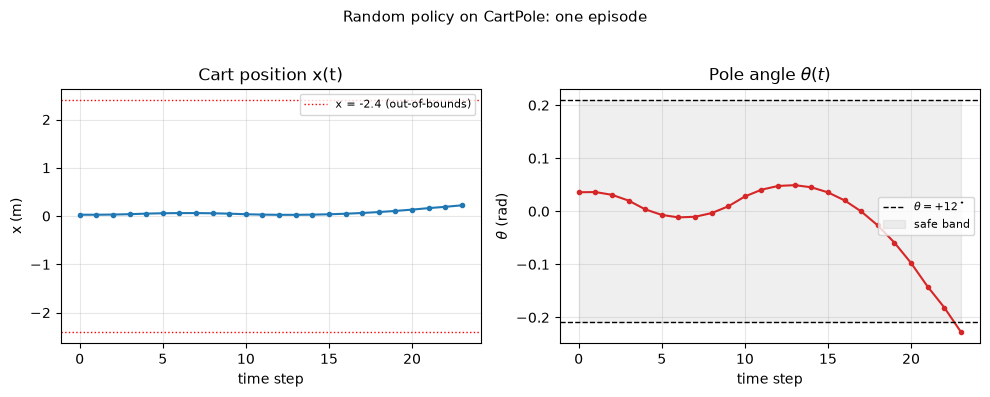

In [6]:
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")
s, _ = env.reset(seed=42)
env.action_space.seed(0)          # 결정적 행동 스트림
xs, th = [s[0]], [s[2]]
while True:
    a = env.action_space.sample()
    s, r, term, trunc, _ = env.step(a)
    xs.append(s[0]); th.append(s[2])
    if term or trunc: break
env.close()
xs, th, t = np.array(xs), np.array(th), np.arange(len(xs))
print(f"에피소드 길이: {len(xs)}스텝, 마지막 막대각도 {np.degrees(th[-1]):.1f}도 "
      f"(±12도 초과 -> terminated)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(t, xs, marker="o", ms=3, color="#1f77b4")
ax1.set_title("Cart position x(t)"); ax1.set_xlabel("time step"); ax1.set_ylabel("x (m)")
ax1.axhline(-2.4, color="r", ls=":", lw=1, label="x = -2.4 (out-of-bounds)")
ax1.axhline(2.4, color="r", ls=":", lw=1)
ax1.legend(fontsize=8); ax1.grid(alpha=.3)

ax2.plot(t, th, marker="o", ms=3, color="#d62728")
ax2.axhline(0.2094, color="k", ls="--", lw=1, label=r"$\theta = +12^\circ$")
ax2.axhline(-0.2094, color="k", ls="--", lw=1)
ax2.fill_between([t.min(), t.max()], -0.2094, 0.2094, color="gray", alpha=.12, label="safe band")
ax2.set_title(r"Pole angle $\theta(t)$"); ax2.set_xlabel("time step"); ax2.set_ylabel(r"$\theta$ (rad)")
ax2.legend(fontsize=8); ax2.grid(alpha=.3)
fig.suptitle("Random policy on CartPole: one episode", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


카트 위치 \(x(t)\)는 거의 제자리를 맴도는 동안 막대 각도
\(\theta(t)\)는 후반부에 급격히 벌어져 \(-12^\circ\)를 넘어
`terminated`가 됩니다 — 관측 벡터 4개 성분 중 **각도**가 종료에 직결된다는
것을 보십시오.


## 7. 이산 vs 연속 행동 공간: CartPole vs Pendulum

연습문제 3에서 확인하라고 한 CartPole(이산)과 `Pendulum-v1`(연속)의 차이를
직접 비교합니다.


In [7]:
ce = gym.make("CartPole-v1")
pe = gym.make("Pendulum-v1")

print("=== CartPole-v1 ===")
print("action_space      :", ce.action_space)
print("observation_space :", ce.observation_space)
print()
print("=== Pendulum-v1 ===")
print("action_space      :", pe.action_space)
print("observation_space :", pe.observation_space)

# Pendulum 보상은 매 스텝 음수 (CartPole의 +1과 부호가 반대)
s, _ = pe.reset(seed=0)
rs = []
for _ in range(5):
    s, r, term, trunc, _ = pe.step(pe.action_space.sample())
    rs.append(r)
print()
print("Pendulum 초기 5스텝 보상:", np.round(rs, 2),
      " (매 스텝 음수 -> 리턴은 음수)")
ce.close(); pe.close()


=== CartPole-v1 ===
action_space      : Discrete(2)
observation_space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

=== Pendulum-v1 ===
action_space      : Box(-2.0, 2.0, (1,), float32)
observation_space : Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)

Pendulum 초기 5스텝 보상: [-0.76 -0.74 -0.86 -1.13 -1.61]  (매 스텝 음수 -> 리턴은 음수)


CartPole의 행동 공간은 `Discrete(2)`(이산), Pendulum은
`Box(-2.0, 2.0, (1,), float32)`(연속)입니다. Pendulum은 매 스텝 **음수**
보상을 주므로 CartPole(+1)과 부호가 반대 — "보상을 **최대화**하려 한다는"
공통 목표(1.1절) 아래에서도, CartPole은 "오래 버티기", Pendulum은 "어떻게
떨어지든 가장 적게 벌금 받기"로 목표가 갈립니다. 이산/연속 차이는
Chapter 9(DQN, 이산)와 Chapter 10~11(정책기반, 연속)에서 어떤 Q함수·정책을
표현할지 결정합니다.
